# Malaria cell CNNs: which one works, and how sure is it?

## Background

I took the two CNNs from the original class project and evaluated them on the
public NIH malaria cell set (27,558 cell photos, half parasitized). ## Setup

The repo records no train/test split, so everything below is computed on the full public
set. Read those numbers as an upper bound on held-out performance.

One sentence per method on why it is the right tool lives next to each step.

In [1]:
import json, numpy as np
from PIL import Image
from IPython.display import display

m = json.load(open("metrics.json"))
err = json.load(open("error_report.json"))
print("files loaded: metrics.json, error_report.json")

files loaded: metrics.json, error_report.json


## Method: pick the winner by measured accuracy

The classes are balanced (13,779 each), so accuracy is not misleading here.
I also recovered the preprocessing each model needs: the repo's inference script
feeds raw 0-255 BGR pixels, but raw pixels saturate `my_model` (same output for
every image, ~50% accuracy). RGB scaled to [0, 1] gives 94.9% on a 2,000-image
check. `malaria_cnn` stays near chance under all four variants I tried.

In [2]:
rows = []
for name in ("my_model", "malaria_cnn"):
    d = m[name]["metrics"]; ci = m[name]["ci"]
    rows.append((name, d["accuracy"], ci["accuracy"], d["auc"], ci["auc"],
                 d["sensitivity"], d["specificity"], m[name]["preprocess"]))
print(f"{'model':12s} {'acc':>7s} {'95% CI':>17s} {'AUC':>6s} {'sens':>6s} {'spec':>6s}  preprocess")
for name, acc, aci, auc, uci, se, sp, pp in rows:
    print(f"{name:12s} {acc:7.4f} [{aci[0]:.4f},{aci[1]:.4f}] {auc:6.4f} {se:6.4f} {sp:6.4f}  {pp['order']}/{pp['scale']:.4f}")
print()
print("Winner: my_model. malaria_cnn's 0.5 threshold is badly placed (sensitivity 0.99, specificity 0.20).")

model            acc            95% CI    AUC   sens   spec  preprocess
my_model      0.9319 [0.9288,0.9348] 0.9577 0.9292 0.9345  rgb/0.0039
malaria_cnn   0.5934 [0.5879,0.5991] 0.7800 0.9917 0.1952  rgb/1.0000

Winner: my_model. malaria_cnn's 0.5 threshold is badly placed (sensitivity 0.99, specificity 0.20).


## Results: confusion matrix with bootstrap confidence intervals

Why bootstrap: accuracy-style metrics have no trustworthy closed-form standard
error, and the percentile bootstrap (Efron and Tibshirani, 1993) makes no
distributional assumptions. 2,000 resamples.

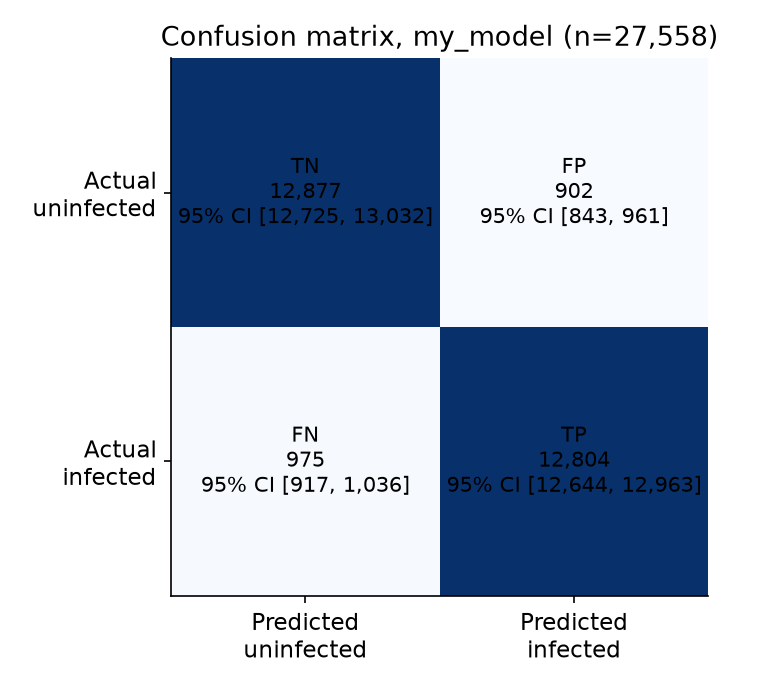

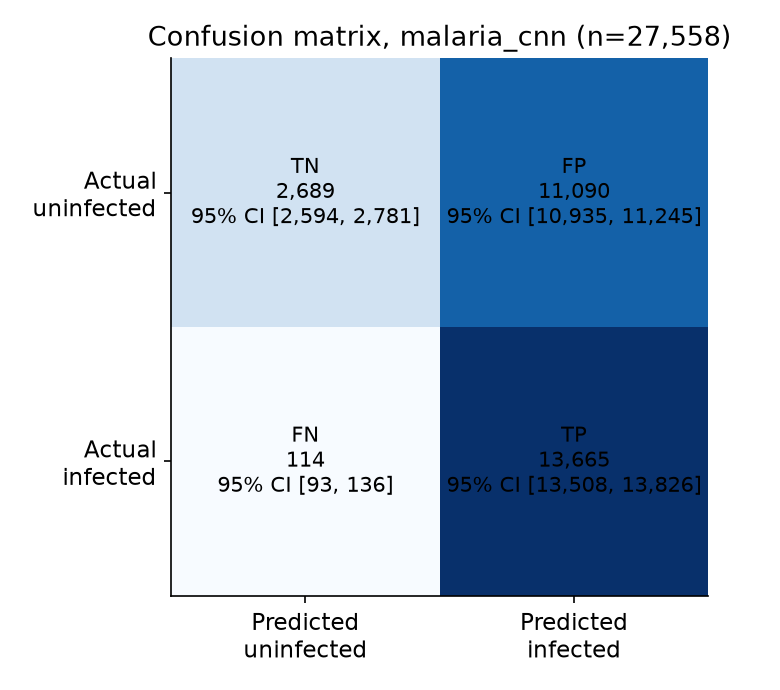

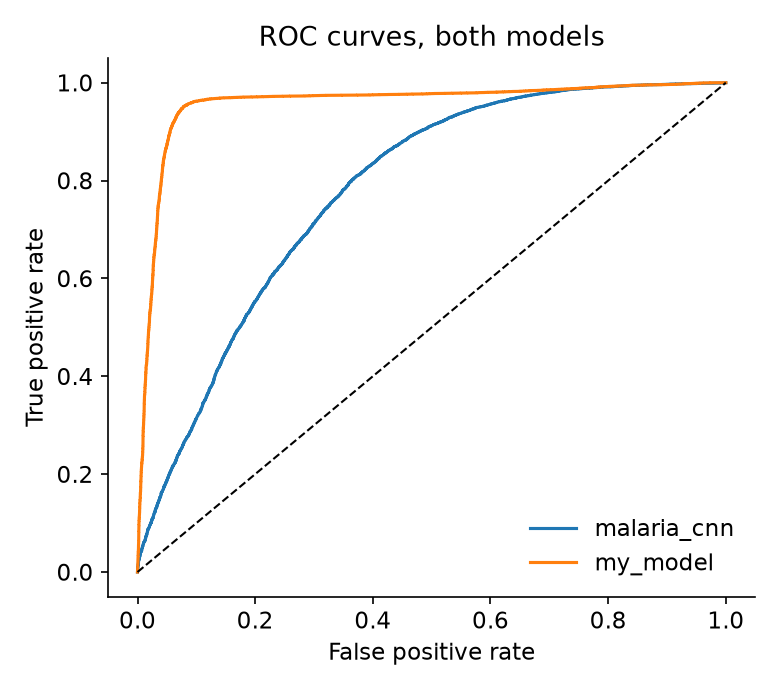

In [3]:
display(Image.open("figures/confusion_my_model.png"))
display(Image.open("figures/confusion_malaria_cnn.png"))
display(Image.open("figures/roc_both.png"))

## Method: calibration, does 0.9 mean 90%?

Why ECE: a screening tool's stated confidence must mean something in the long
run. Expected calibration error over 15 equal-width bins (Guo et al., 2017)
measures exactly the gap between claimed and observed frequency.

ECE(my_model) = 0.1032


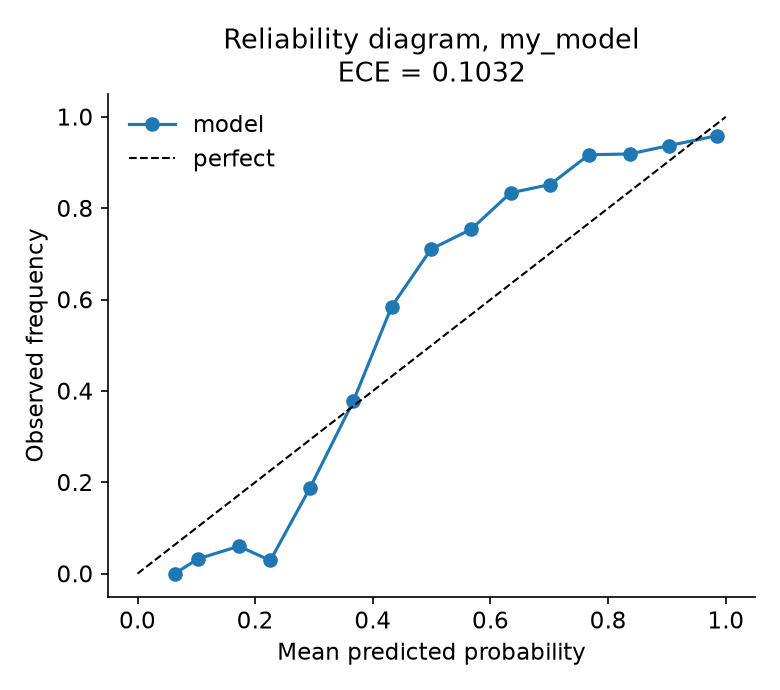

The curve sits above the diagonal in the middle: cells scored 0.4-0.7 are
infected more often than claimed. Under-confident, the safer direction.


In [4]:
print(f"ECE(my_model) = {err['ece']:.4f}")
display(Image.open("figures/calibration_winner.png"))
print("The curve sits above the diagonal in the middle: cells scored 0.4-0.7 are")
print("infected more often than claimed. Under-confident, the safer direction.")

## Method: test-time augmentation uncertainty

Why TTA: showing each cell to the model in 8 geometric views (4 rotations, with
and without horizontal flip) estimates input-dependent uncertainty without
retraining (Ayhan and Berens, 2018). Deterministic views keep the browser demo
reproducible.

n = 2000 cells, 8 views each
mean SD of P(infected) across views : 0.0550
mean 95% interval width             : 0.1765
  correctly classified              : 0.1750
  misclassified                     : 0.2013


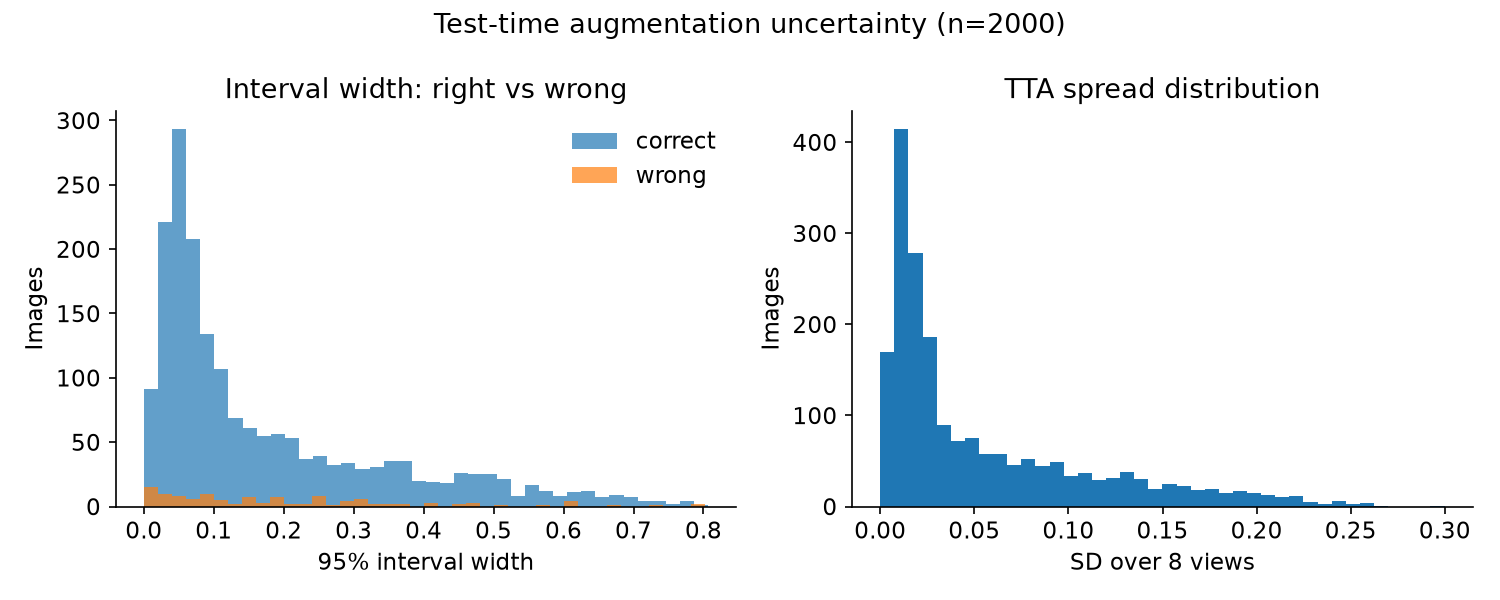

In [5]:
t = err["tta"]
print(f"n = {t['n']} cells, 8 views each")
print(f"mean SD of P(infected) across views : {t['mean_sd_all']:.4f}")
print(f"mean 95% interval width             : {t['mean_width_all']:.4f}")
print(f"  correctly classified              : {t['mean_width_correct']:.4f}")
print(f"  misclassified                     : {t['mean_width_wrong']:.4f}")
display(Image.open("figures/tta_spread.png"))

## Results: error analysis

No life-cycle stage labels exist in this data (file names carry only a cell
ID), so stage-by-stage analysis is impossible. Instead I compared misclassified
cells to correctly classified ones on simple image properties a microscopist
would recognize, and plotted the worst misses.

brightness  errors 0.446 (sd 0.050)  vs  correct 0.470 (sd 0.047)
contrast    errors 0.292 (sd 0.025)  vs  correct 0.290 (sd 0.022)
saturation  errors 0.200 (sd 0.085)  vs  correct 0.173 (sd 0.079)
redness     errors 0.291 (sd 0.038)  vs  correct 0.292 (sd 0.034)

n_errors = 1877


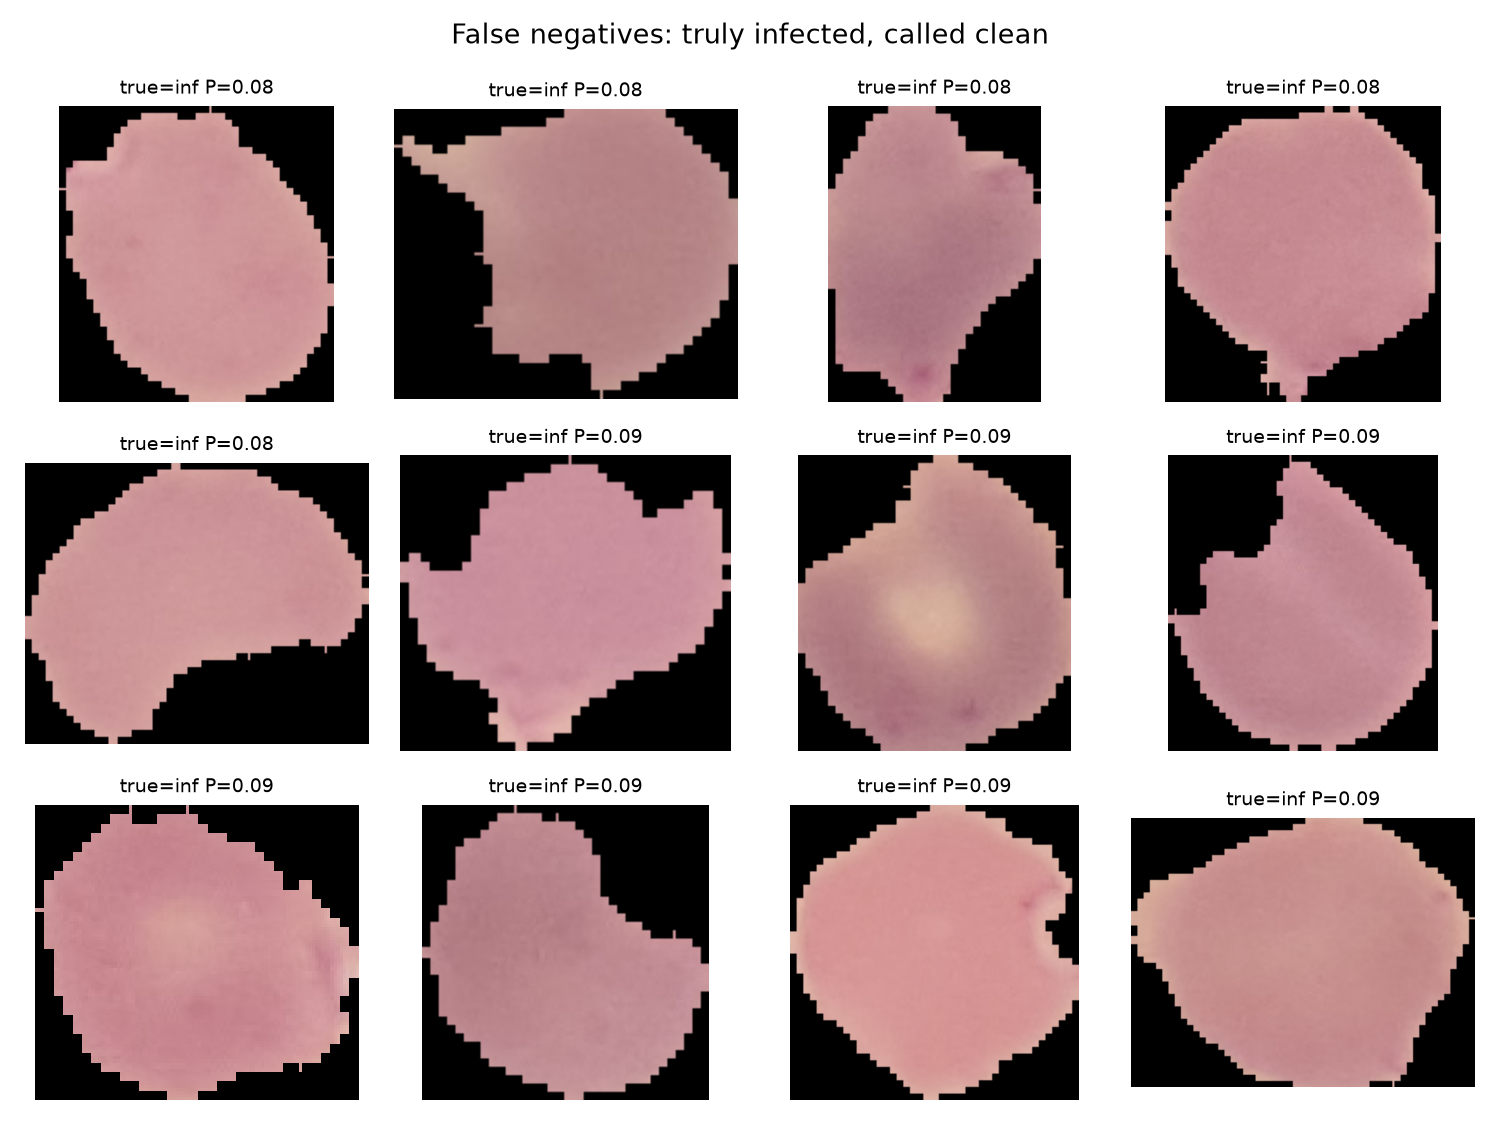

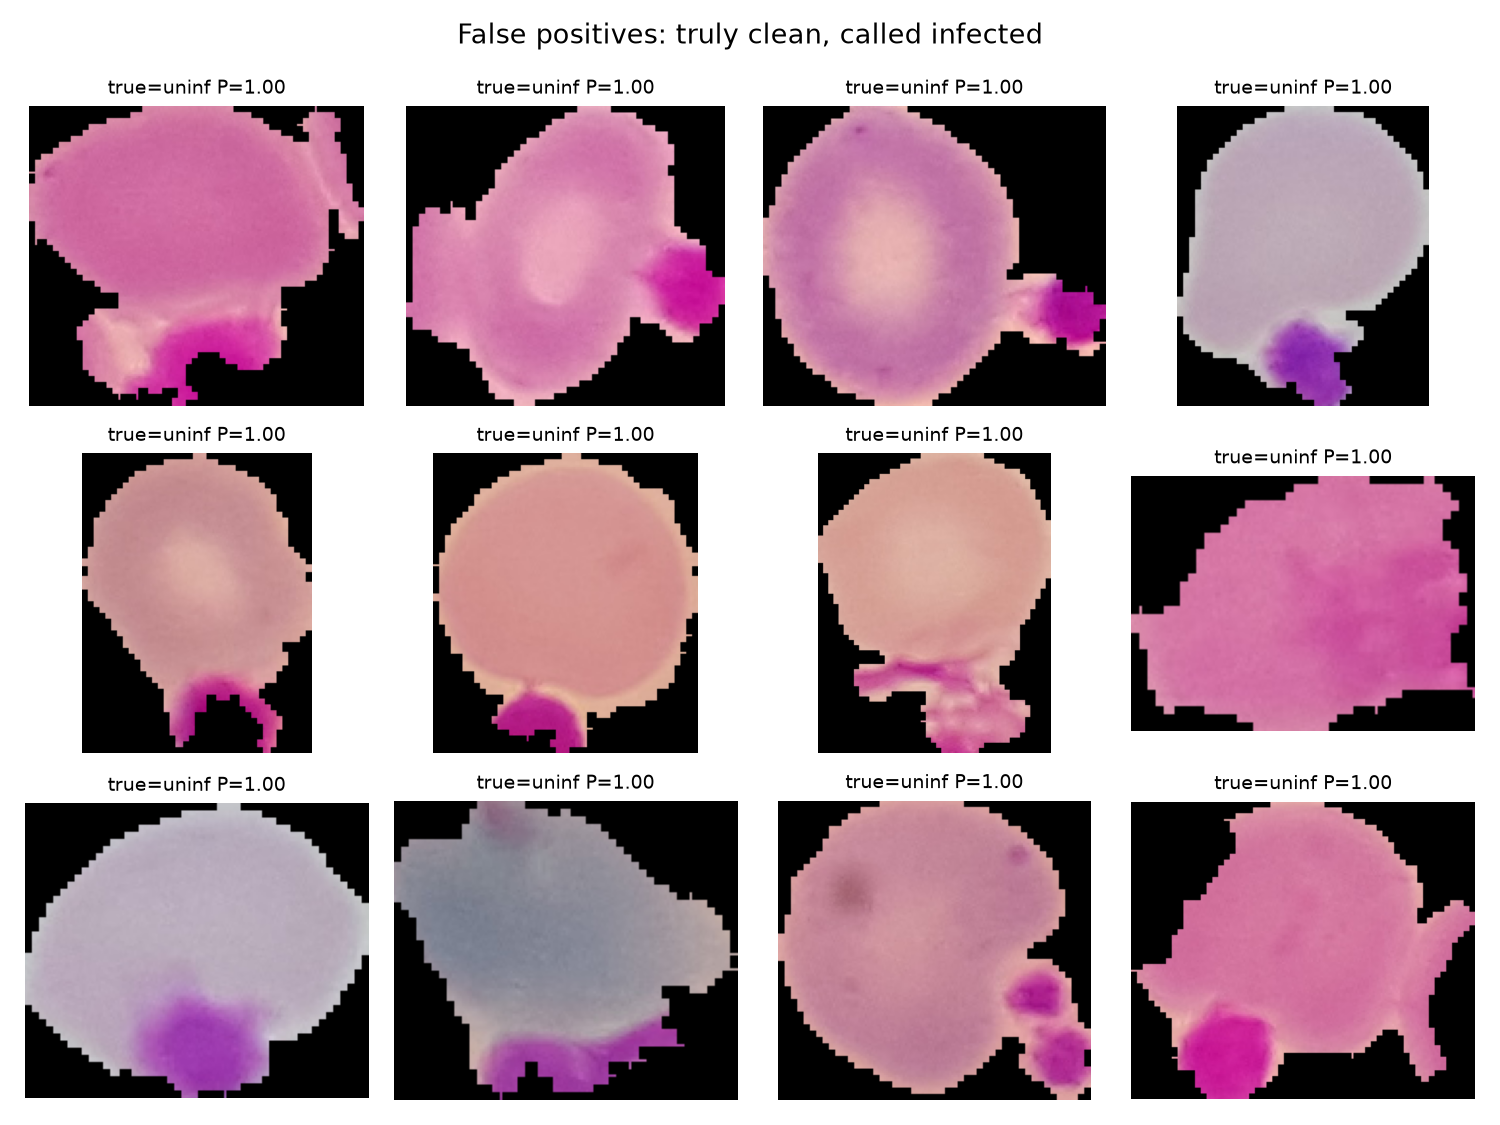

In [6]:
s = err["summary"]
for k, v in s.items():
    print(f"{k:11s} errors {v['errors_mean']:.3f} (sd {v['errors_sd']:.3f})  vs  correct {v['correct_mean']:.3f} (sd {v['correct_sd']:.3f})")
print(f"\nn_errors = {err['n_errors']}")
display(Image.open("figures/errors_false_negatives.png"))
display(Image.open("figures/errors_false_positives.png"))

## Takeaway

`my_model` reaches 93.2% accuracy (95% CI 0.929-0.935) on the full NIH set,
next to the published 92.7% for a small custom CNN. It is slightly
under-confident mid-range (ECE 0.103) and its TTA intervals run a little wider
on the cells it gets wrong. The honest caveats: the original train split is
unknown, so treat this as an upper bound; and this classifies cropped single
cells, which is one step of real diagnosis, not the whole thing.